# map reduce

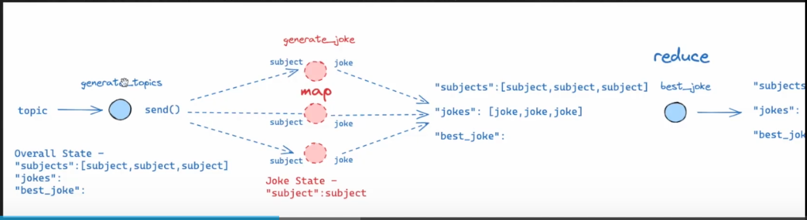


# 定义模型

In [179]:
from config_utils import api_key,base_url
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
            model="Pro/MiniMaxAI/MiniMax-M2.5",
            api_key=api_key,
            base_url=base_url,
            streaming=True
        )



定义prompt和数据格式

In [180]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from langgraph.types import Send

subject_prompt ='''生成一个以;分隔的列表,包含2到5个与以下主题相关的例子:{topic}'''

joke_prmopt = '''生成一个关于{subject}的笑话'''

best_prompt='''以下是一些关于{topic}的笑话,选出最好的一个,返回最佳笑话的id {jokes}'''

class Subjects(BaseModel):
    subject:list[str]

class Joke(BaseModel):
    joke:str

class BestJoke(BaseModel):
    id:int = Field(ge=0,description='best joke id')


# 定义节点状态

In [181]:
from typing import Annotated
import operator

class OverallState(BaseModel):
    topic:str = Field(description='topic to generate joke for')
    subjects:list = Field(default_factory=list)
    jokes:Annotated[list,operator.add] = Field(default_factory=list)
    best_selected_joke:str = ""

class JokeState(BaseModel):
    subject:str = Field(description='subject to generate joke for')


# 定义节点和图

In [182]:
# 生成笑话主题节点
def generate_topics(state: OverallState) -> dict:

    prompt = subject_prompt.format(topic=state.topic)

    response = llm.with_structured_output(Subjects).invoke(prompt)

    subjects = response.subject

    if len(subjects) == 1 and ";" in subjects[0]:

        subjects = [s.strip() for s in subjects[0].split(";") if s.strip()]

    return {

        "subjects": subjects

    }

# 生成笑话节点
def generate_jokes(state:JokeState) ->dict:
    prompt = joke_prmopt.format(subject=state["subject"])
    response = llm.with_structured_output(Joke).invoke(prompt)
    return {
        "jokes":[response.joke]
    }

def continue_to_joke(state:OverallState):
    # Send("目标节点名", 要传过去的状态数据) 动态路由 + 派发任务
    # 并行分发
    # [
    #    Send("generate_jokes", {"suject": "猫"}),
    #    Send("generate_jokes", {"suject": "狗"}),
    #    Send("generate_jokes", {"suject": "鹦鹉"}),
    # ]
    return [Send("generate_jokes",{"subject":s}) for s in state.subjects]

def best_joke(state: OverallState) -> dict:

    jokes = "\n\n".join(state.jokes)

    prompt = best_prompt.format(topic=state.topic, jokes=jokes)

    response = llm.with_structured_output(BestJoke).invoke(prompt)

    return {

        "best_selected_joke": state.jokes[response.id]

    }


graph_builder = StateGraph(OverallState)

graph_builder.add_node(generate_topics)
graph_builder.add_node(generate_jokes)
graph_builder.add_node(best_joke)

graph_builder.add_edge(START,"generate_topics")

graph_builder.add_conditional_edges(
    "generate_topics",
    continue_to_joke,
    ["generate_jokes"]
)
graph_builder.add_edge("generate_jokes","best_joke")
graph_builder.add_edge("best_joke",END)

graph = graph_builder.compile()

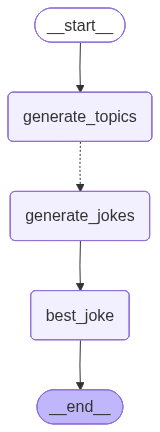

In [183]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [184]:
for s in graph.stream({"topic":"动物"}):
    print(s)

/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Subjects(subject=['狗', ...', '狮子', '熊猫']), input_type=Subjects])
  return self.__pydantic_serializer__.to_python(


{'generate_topics': {'subjects': ['狗', '猫', '大象', '狮子', '熊猫']}}


/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Joke(joke='为什么狗...汪”（万元）！'), input_type=Joke])
  return self.__pydantic_serializer__.to_python(


{'generate_jokes': {'jokes': ['为什么狗狗不适合做银行职员？\n\n因为它们总是说“汪汪”（万元）！']}}


/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Joke(joke='为什么大...风纪委员吓跑！'), input_type=Joke])
  return self.__pydantic_serializer__.to_python(


...

/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Joke(joke='为什么熊...不够“熊”嘛！'), input_type=Joke])
  return self.__pydantic_serializer__.to_python(


{'generate_jokes': {'jokes': ['为什么熊猫每次去中国餐厅都会点两份竹子？\n\n因为它觉得一份不够“熊”嘛！']}}


/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Joke(joke='为什么狮...长‘拔’牙了！'), input_type=Joke])
  return self.__pydantic_serializer__.to_python(
/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Joke(joke='为什么猫...虎’（hot）猫！'), input_type=Joke])
  return self.__pydantic_serializer__.to_python(


{'generate_jokes': {'jokes': ['为什么狮子不适合当外科医生？\n\n因为它们太擅长‘拔’牙了！']}}
{'generate_jokes': {'jokes': ['为什么猫喜欢晒太阳？\n\n因为它们想当‘虎’（hot）猫！']}}
{'best_joke': {'best_selected_joke': '为什么猫喜欢晒太阳？\n\n因为它们想当‘虎’（hot）猫！'}}


/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=BestJoke(id=1), input_type=BestJoke])
  return self.__pydantic_serializer__.to_python(
